# 2. Machine Learning for Regression

In [1]:
import pandas as pd
import numpy as np

### 2.2 Data Preparation

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'

In [3]:
# !wget $data

In [4]:
!ls -lrt

total 1456
-rw-rw-rw- 1 codespace codespace 1475504 Mar 22 06:01 data.csv
-rw-rw-rw- 1 codespace codespace   11428 Mar 22 12:54 car-price-prediction.ipynb


In [5]:
df = pd.read_csv('data.csv')

In [6]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [7]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='str')

In [8]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [9]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [10]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [11]:
df.dtypes == 'str'

make                  True
model                 True
year                 False
engine_fuel_type      True
engine_hp            False
engine_cylinders     False
transmission_type     True
driven_wheels         True
number_of_doors      False
market_category       True
vehicle_size          True
vehicle_style         True
highway_mpg          False
city_mpg             False
popularity           False
msrp                 False
dtype: bool

In [12]:
string_cols = list(df.dtypes[df.dtypes == 'str'].index) # getting string columns with dtypes and then convering to pythong list
string_cols

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [13]:
for col in string_cols:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [14]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


### 2.3 Exploratory data analysis

In [15]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique)
    print()

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
<bound method IndexOpsMixin.nunique of 0            bmw
1            bmw
2            bmw
3            bmw
4            bmw
          ...   
11909      acura
11910      acura
11911      acura
11912      acura
11913    lincoln
Name: make, Length: 11914, dtype: str>

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
<bound method IndexOpsMixin.nunique of 0        1_series_m
1          1_series
2          1_series
3          1_series
4          1_series
            ...    
11909           zdx
11910           zdx
11911           zdx
11912           zdx
11913        zephyr
Name: model, Length: 11914, dtype: str>

year
[2011 2012 2013 1992 1993]
<bound method IndexOpsMixin.nunique of 0        2011
1        2011
2        2011
3        2011
4        2011
         ... 
11909    2012
11910    2012
11911    2012
11912    2013
11913    2006
Name: year, 

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

(array([9.098e+03, 2.003e+03, 3.170e+02, 1.320e+02, 1.110e+02, 9.200e+01,
        5.100e+01, 4.100e+01, 1.500e+01, 1.300e+01, 1.500e+01, 1.300e+01,
        4.000e+00, 2.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 2.000e+00, 0.000e+00, 0.000e+00,
        2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([2.00000000e+03, 4.32780400e+04, 8.45560800e+04, 1.25834120e+05,
        1.67112160e+05, 2.08390200e+05, 2.49668240e+05, 2.90946280e+05,
        3.32224320e+05, 3.73502360e+05, 4.14780400e+05, 4.56058440e+05,
        4.97336480e+05, 5.38614520e+05, 5.79892560e+05, 6.21170600e+05,
        6.62448640e+05, 7.03726680e+05, 7.45004720e+05, 7.86282760e+05,
        8.275608

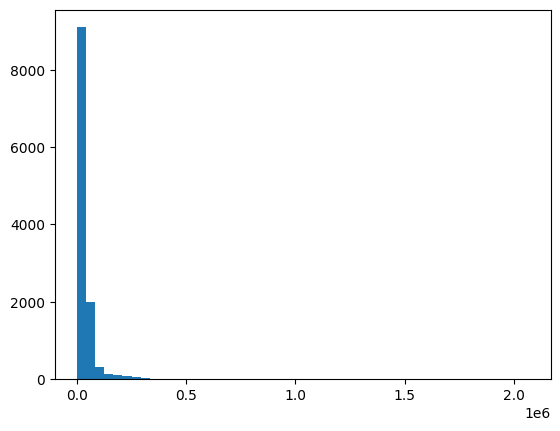

In [17]:
plt.hist(df.msrp, bins=50) # data seems to have long tail (0.5 to 2.0) check plotting. this mean data is not distributed well

(array([1571.,   55.,   13.,    7.,   20.,   53.,  223.,  305.,  371.,
         508.,  621.,  684.,  710.,  622.,  637.,  581.,  527.,  467.,
         408.,  365.,  332.,  274.,  250.,  203.,  189.,  153.,  123.,
         102.,   71.,   85.,   85.,   92.,   66.,   49.,   46.,   33.,
          29.,   36.,   24.,   39.,   21.,   39.,   31.,   22.,   32.,
          19.,   23.,   21.,   18.,   21.]),
 array([ 2000.,  3959.,  5918.,  7877.,  9836., 11795., 13754., 15713.,
        17672., 19631., 21590., 23549., 25508., 27467., 29426., 31385.,
        33344., 35303., 37262., 39221., 41180., 43139., 45098., 47057.,
        49016., 50975., 52934., 54893., 56852., 58811., 60770., 62729.,
        64688., 66647., 68606., 70565., 72524., 74483., 76442., 78401.,
        80360., 82319., 84278., 86237., 88196., 90155., 92114., 94073.,
        96032., 97991., 99950.]),
 <BarContainer object of 50 artists>)

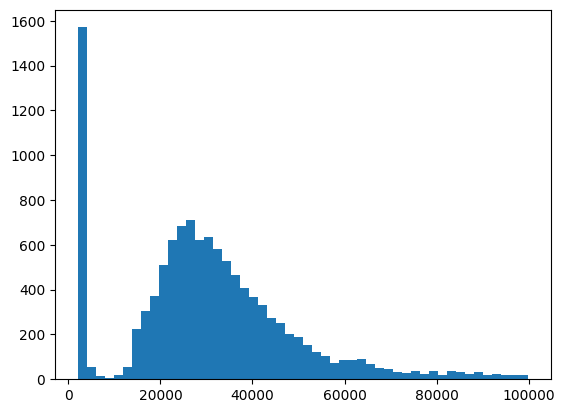

In [18]:
plt.hist(df.msrp[df.msrp < 100000], bins=50) # filtering msrp will have normal data distribution for price. but we are excluding lots of data

In [19]:
# converting below values in log can been seen is more closer
np.log([1, 10, 1000, 100000])

array([ 0.        ,  2.30258509,  6.90775528, 11.51292546])

In [20]:
# if values have zero then it wil complain. To handle this we add 1 to all the values.`
np.log([0, 1, 10, 1000, 100000]) 

/tmp/ipykernel_3897/3257606447.py:2: RuntimeWarning: divide by zero encountered in log
  np.log([0, 1, 10, 1000, 100000])


array([       -inf,  0.        ,  2.30258509,  6.90775528, 11.51292546])

In [21]:
# adding 1 to each value will handle zero case. for this numpy have in-built function. check next cell.
np.log([0 + 1, 1 + 1, 10 + 1, 1000 + 1, 100000 + 1]) 

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

In [22]:
np.log1p([0, 1, 10, 1000, 100000])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

(array([1.211e+03, 1.230e+02, 9.900e+01, 9.200e+01, 4.800e+01, 2.300e+01,
        1.800e+01, 1.300e+01, 7.000e+00, 5.000e+00, 4.000e+00, 1.000e+01,
        2.300e+01, 5.300e+01, 2.630e+02, 3.850e+02, 6.410e+02, 1.000e+03,
        1.261e+03, 1.372e+03, 1.238e+03, 1.070e+03, 8.200e+02, 5.590e+02,
        3.490e+02, 2.280e+02, 1.870e+02, 1.500e+02, 9.700e+01, 7.700e+01,
        7.100e+01, 5.400e+01, 5.900e+01, 9.300e+01, 5.900e+01, 5.100e+01,
        3.700e+01, 1.400e+01, 2.100e+01, 1.900e+01, 3.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 4.000e+00,
        1.000e+00, 1.000e+00]),
 array([ 7.60140233,  7.74019585,  7.87898936,  8.01778287,  8.15657639,
         8.2953699 ,  8.43416341,  8.57295692,  8.71175044,  8.85054395,
         8.98933746,  9.12813098,  9.26692449,  9.405718  ,  9.54451151,
         9.68330503,  9.82209854,  9.96089205, 10.09968557, 10.23847908,
        10.37727259, 10.5160661 , 10.65485962, 10.79365313, 10.93244664,
        11.

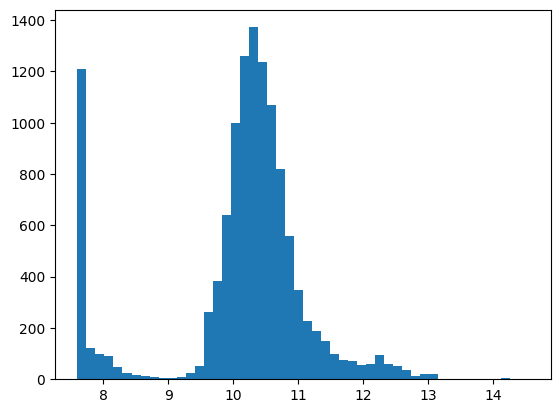

In [23]:
# We will convert value to log and plot as this will make distribution more closer to each other. As shown in examples above.
# after log value hist plot have normalise distribution and very less long tail values.
log_price = np.log1p(df.msrp)
plt.hist(log_price, bins=50)

##### Missing values

In [24]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

### 2.4 Setting up the validation framework

In [25]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [26]:
n_train, n_val, n_test

(7150, 2382, 2382)

##### getting random sequece of data from dataframe for train

In [27]:
idx = np.arange(n)
rng = np.random.default_rng(seed=0)
rng.shuffle(idx)

In [28]:
idx

array([11744,  7096,   414, ...,  5921, 11215,   607], shape=(11914,))

In [29]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train: n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [30]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
11744,nissan,xterra,2013,regular_unleaded,261.0,6.0,automatic,four_wheel_drive,4.0,NaN,midsize,4dr_suv,20,15,2009,26900
7096,mazda,mx-3,1993,regular_unleaded,130.0,6.0,manual,front_wheel_drive,2.0,hatchback,compact,2dr_hatchback,26,20,586,2000
414,bmw,4_series_gran_coupe,2015,premium_unleaded_(required),240.0,4.0,automatic,all_wheel_drive,4.0,luxury,midsize,sedan,33,22,3916,42300
9142,cadillac,seville,2002,regular_unleaded,300.0,8.0,automatic,front_wheel_drive,4.0,"luxury,performance",large,sedan,25,16,1624,49705
1495,cadillac,ats_coupe,2015,premium_unleaded_(recommended),272.0,4.0,automatic,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,31,21,1624,47095


In [31]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [32]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,nissan,xterra,2013,regular_unleaded,261.0,6.0,automatic,four_wheel_drive,4.0,NaN,midsize,4dr_suv,20,15,2009,26900
1,mazda,mx-3,1993,regular_unleaded,130.0,6.0,manual,front_wheel_drive,2.0,hatchback,compact,2dr_hatchback,26,20,586,2000
2,bmw,4_series_gran_coupe,2015,premium_unleaded_(required),240.0,4.0,automatic,all_wheel_drive,4.0,luxury,midsize,sedan,33,22,3916,42300
3,cadillac,seville,2002,regular_unleaded,300.0,8.0,automatic,front_wheel_drive,4.0,"luxury,performance",large,sedan,25,16,1624,49705
4,cadillac,ats_coupe,2015,premium_unleaded_(recommended),272.0,4.0,automatic,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,31,21,1624,47095


In [33]:
df_val.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,dodge,dakota,2009,regular_unleaded,210.0,6.0,automatic,rear_wheel_drive,4.0,flex_fuel,compact,extended_cab_pickup,20,15,1851,23710
1,gmc,s-15,1990,regular_unleaded,160.0,6.0,manual,four_wheel_drive,2.0,NaN,compact,regular_cab_pickup,19,15,549,2000
2,bmw,3_series,2015,premium_unleaded_(required),180.0,4.0,automatic,all_wheel_drive,4.0,luxury,midsize,sedan,35,23,3916,34950
3,aston_martin,dbs,2012,premium_unleaded_(required),510.0,12.0,automatic,rear_wheel_drive,2.0,"exotic,high-performance",midsize,convertible,18,12,259,290861
4,volkswagen,tiguan,2016,premium_unleaded_(recommended),200.0,4.0,automatic,all_wheel_drive,4.0,crossover,compact,4dr_suv,26,20,873,33365


In [34]:
df_test.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,nissan,altima,2015,regular_unleaded,270.0,6.0,automatic,front_wheel_drive,4.0,performance,midsize,sedan,32,22,2009,29830
1,volkswagen,golf_r,2015,premium_unleaded_(recommended),292.0,4.0,automated_manual,all_wheel_drive,4.0,"hatchback,factory_tuner,high-performance",compact,4dr_hatchback,30,23,873,39090
2,lotus,exige,2011,premium_unleaded_(recommended),240.0,4.0,manual,rear_wheel_drive,2.0,"exotic,high-performance",compact,coupe,26,20,613,65690
3,hyundai,elantra,2016,regular_unleaded,145.0,4.0,automatic,front_wheel_drive,4.0,NaN,compact,sedan,38,28,1439,19700
4,ford,focus,2017,electric,NaN,0.0,direct_drive,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,99,110,5657,29120


In [35]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [36]:
# extracting target value (in this dataset price `msrp` is the target value): g(X) ~ y, keep it as log value.
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [37]:
y_train

array([10.19991874,  7.60140233, 10.65256601, ..., 10.57543663,
        7.60140233, 10.49241246], shape=(7150,))

In [38]:
len(y_train), len(y_val), len(y_test)

(7150, 2382, 2382)

In [39]:
# deleting msrp so that this column is not used in training by mistake.

del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

### 2.5 Linear regression

In [48]:
df_train.iloc[453] # random index value for checking

make                                 rolls-royce
model                                    phantom
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              4.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                              sedan
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 968, dtype: object

#### formula
for single vector: 

$g(x_n) = w_0 + \sum_{i=1}^{n} w_i x_i$


*$w_0$ is the bias term (the base value).


#### applying the formula

If we expand the summation ($\sum$) for our 3 features, the linear regression formula looks like this:

for index 453 from data set (here this number only represent data for 453 row):

$g(x_{453}) = w_0 + w_1 x_1 + w_2 x_2 + w_3 x_3$


In [56]:
xi = [453, 11, 86] # feature value for index 453 [engine_hp, city_mpg, popularity]
w0 = 7.17 # bias term (base value)
w = [0.01, 0.04, 0.002] # each feature weight (taken some random number, later understand how to calculate)

In [58]:
def linear_regression(xi):
    n = len(xi)
    prediction = w0
    for j in range(n):
        prediction = prediction + (xi[j] * w[j])

    return prediction
    

In [61]:
pred = linear_regression(xi)
pred

12.312

In [63]:
# Converting to actual value using exponention as prices were conveted to log earlier
pred_msrp = np.expm1(pred)
pred_msrp

np.float64(222347.2221101062)

In [65]:
np.log1p(pred_msrp) # verification

np.float64(12.312)